In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv")
print(df)

         model  year  price transmission  mileage fuelType  tax   mpg  \
0       Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7   
1        Focus  2018  14000       Manual     9083   Petrol  150  57.7   
2        Focus  2017  13000       Manual    12456   Petrol  150  57.7   
3       Fiesta  2019  17500       Manual    10460   Petrol  145  40.3   
4       Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7   
...        ...   ...    ...          ...      ...      ...  ...   ...   
17961    B-MAX  2017   8999       Manual    16700   Petrol  150  47.1   
17962    B-MAX  2014   7499       Manual    40700   Petrol   30  57.7   
17963    Focus  2015   9999       Manual     7010   Diesel   20  67.3   
17964       KA  2018   8299       Manual     5007   Petrol  145  57.7   
17965    Focus  2015   8299       Manual     5007   Petrol   22  57.7   

       engineSize  
0             1.0  
1             1.0  
2             1.0  
3             1.5  
4             1.0  
...

In [3]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


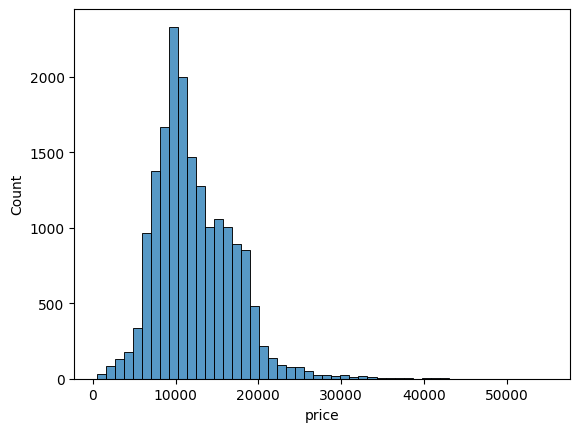

In [4]:
sns.histplot(x="price", data = df, bins= 50)
plt.show()

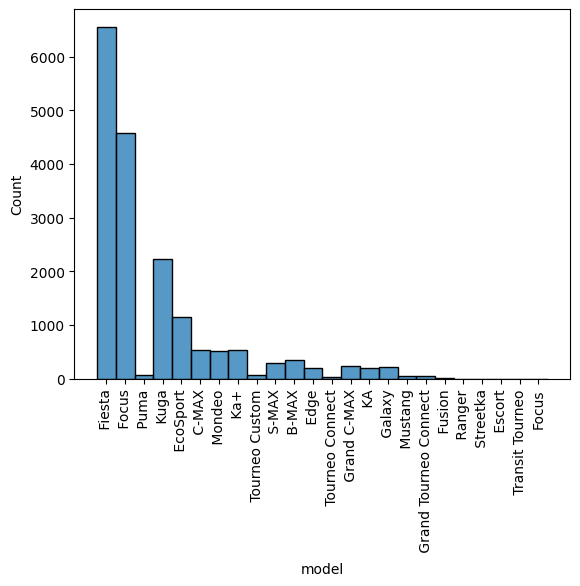

In [5]:
sns.histplot(x="model", data=df)
plt.xticks(rotation=90)
plt.show()

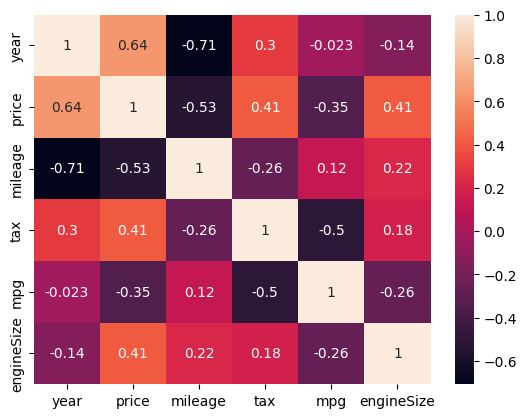

In [6]:
heat = df.corr(numeric_only = True)
sns.heatmap(heat, annot=True)
plt.show()

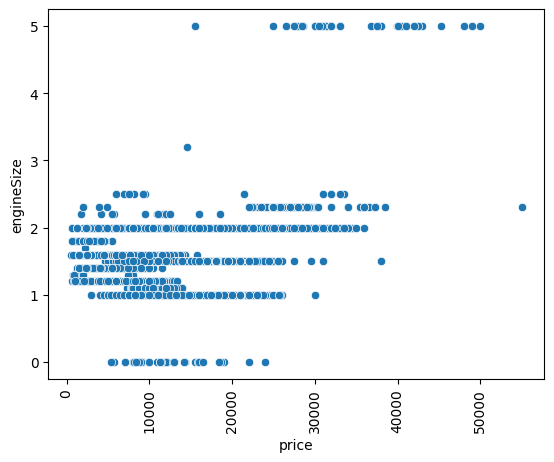

In [7]:
sns.scatterplot(x="price", y="engineSize", data=df)
plt.xticks(rotation=90)
plt.show()

In [8]:
print(df.columns)

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')


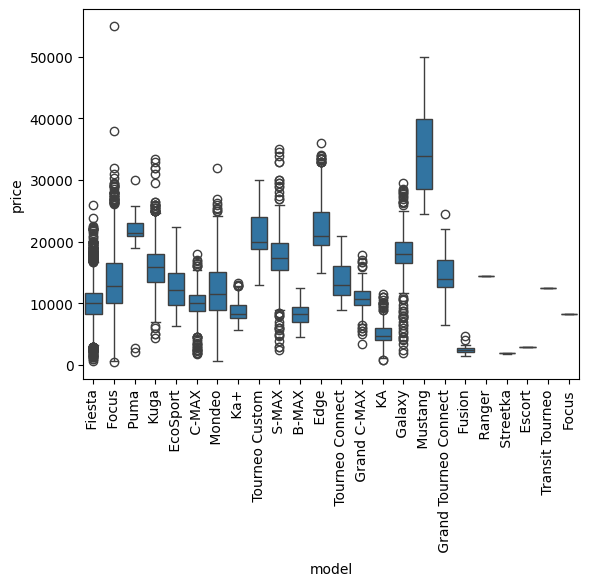

In [9]:
sns.boxplot(x="model", y ="price", data=df)
plt.xticks(rotation=90)
plt.show()

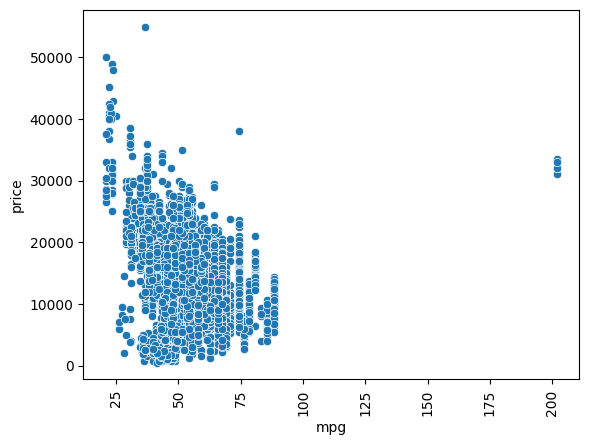

In [10]:
sns.scatterplot(x="mpg", y="price", data = df)
plt.xticks(rotation=90)
plt.show()


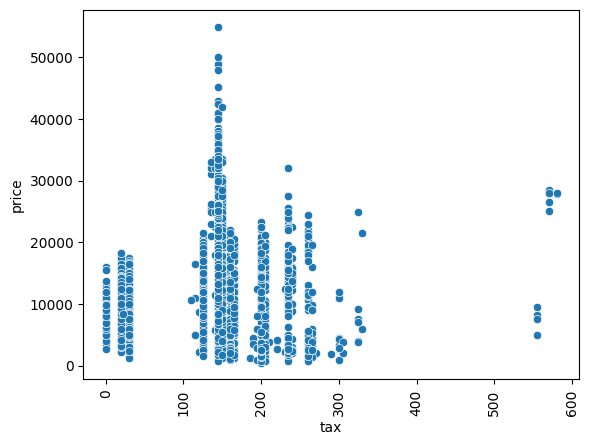

In [11]:
sns.scatterplot(x="tax", y="price", data = df)
plt.xticks(rotation=90)
plt.show()

one hot encoding code


In [12]:
x_encoding = df.copy()
numeric_col = x_encoding.select_dtypes(include='object').columns
print(numeric_col)
x_encoding = pd.get_dummies(x_encoding, columns=['model', 'transmission', 'fuelType'])
x_encoding = x_encoding.astype(int)
print(x_encoding)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split   

x = x_encoding.drop("price", axis=1)
y = x_encoding["price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
scaler = StandardScaler()
scale_cols = ["year", "mileage", "tax", "mpg"]

x_train[scale_cols] = scaler.fit_transform(x_train[scale_cols])
x_test[scale_cols] = scaler.transform(x_test[scale_cols])

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

from sklearn.metrics import r2_score, mean_absolute_error   
print(f"the mse is {mean_absolute_error(y_test, y_pred)}")

print(f"the r2 score is {r2_score(y_test, y_pred)}")



Index(['model', 'transmission', 'fuelType'], dtype='object')
       year  price  mileage  tax  mpg  engineSize  model_ B-MAX  model_ C-MAX  \
0      2017  12000    15944  150   57           1             0             0   
1      2018  14000     9083  150   57           1             0             0   
2      2017  13000    12456  150   57           1             0             0   
3      2019  17500    10460  145   40           1             0             0   
4      2019  16500     1482  145   48           1             0             0   
...     ...    ...      ...  ...  ...         ...           ...           ...   
17961  2017   8999    16700  150   47           1             1             0   
17962  2014   7499    40700   30   57           1             1             0   
17963  2015   9999     7010   20   67           1             0             0   
17964  2018   8299     5007  145   57           1             0             0   
17965  2015   8299     5007   22   57           

linear coding

in this line i tried to find which col gives more r2_score so this fails to give good accuracy 

In [13]:
# from sklearn.preprocessing import LabelEncoder
# from sklearn.preprocessing import StandardScaler

# x_linear = df.copy()

# le = LabelEncoder()

# x_linear["model"] = le.fit_transform(x_linear["model"])
# x_linear["transmission"] = le.fit_transform(x_linear["transmission"])
# x_linear["fuelType"] = le.fit_transform(x_linear["fuelType"])

# scaler = StandardScaler()

# x_linear = pd.DataFrame(
#     scaler.fit_transform(x_linear),
#     columns=x_linear.columns,
#     index=x_linear.index
# )

# x = x_linear.drop("price", axis=1)
# y = x_linear["price"]
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# x_train = scaler.fit_transform(x_train)
# x_test = scaler.transform(x_test)

# model.fit(x_train, y_train)
# y_pred = model.predict(x_test)

# print(f"the mse is {mean_absolute_error(y_test, y_pred)}")

# print(f"the r2 score is {r2_score(y_test, y_pred)}")






In [14]:
df.columns
df.dtypes


model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

In [15]:
car_model = " Fiesta"
year = 2018
transmission = "Manual"
mileage = 35000
fuel_type = "Petrol"
tax = 145
mpg = 55
engine_size = 1.0

user = pd.DataFrame({
    "model":[model],
    "year":[year],
    "transmission":[transmission],
    "mileage":[mileage],
    "fuelType":[fuel_type],
    "tax":[tax],
    "mpg":[mpg],
    "engineSize":[engine_size]
})

user = pd.get_dummies(
    user,
    columns=["model","transmission","fuelType"]
)
user = user.reindex(columns=x.columns, fill_value=0)
user[scale_cols] = scaler.transform(user[scale_cols])


prediction = model.predict(user)

print(f"the price of car is {prediction}")

the price of car is [13691.82066696]
